In [ ]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.sandbox.stats.multicomp import multipletests

np.random.seed(7)
sns.set_theme(context="notebook", style='whitegrid')

In [ ]:
def plot_signal_strandwise(forward: np.array, reverse: np.array, gates: list, width: int, title: str, ylabel: str, error_kind: int):
    window_scores = []
    if forward is not None:
        max_l = len(forward)
        if reverse is not None:
            # both strands are submitted
            for l, r in gates:
                if l-1 < width or max_l < l-1+width:
                    continue
                window_scores += [forward[l-1-width:l-1+width] + reverse[l-1-width:l-1+width][::-1]]
        else:
            # only forward
            for l, r in gates:
                if l-1 < width or max_l < l-1+width:
                    continue
                window_scores += [forward[l-1-width:l-1+width]]
    else:
        if reverse is not None:
            # only reverse
            max_l = len(reverse)
            for l, r in gates:
                if l-1 < width or max_l < l-1+width:
                    continue
                window_scores += [reverse[l-1-width:l-1+width][::-1]]
    
    window_scores = np.array(window_scores)

    plt.figure(figsize=(8, 5))
    sns.lineplot(x=np.tile(np.arange(-width, width), len(window_scores)), y=window_scores.ravel(), 
            estimator=np.mean, errorbar=error_kind, legend='full')
    plt.xlabel('Nucleotides from the site start')
    plt.ylabel(ylabel)
    plt.title(title)

In [4]:
# read files
terminome = pd.read_excel('Supplementary_Table_S1.xlsx', header=1)
fpkm = pd.read_excel('ChRNA_Seq_AP000423.1.FPKM_combined.xlsx')

gates = []
with open('AP000423.1_Trusted_GCSs_0.01.bed', 'r') as f_bed:
    for line in f_bed:
            start, end = line.strip().split('\t')[1:3]
            gates.append([int(start), int(end)])

fpkm = fpkm[['st', 'end', 'FPKM_average', 'gene_strand']]
terminome = terminome[["WT_3'ends_F", "WT_3'ends_R"]]

# truncate all to 120kb
fpkm = fpkm[fpkm['end'] <= 120000]
terminome = terminome.iloc[:120000]
gates = np.array(gates)[np.array(gates)[:, 1] <= 120000]

In [ ]:
#filter gates by defined fpkm intervals
epsilon = 150 # exclude gates which epsilon vicinity is outside genes
mask = ((fpkm['st'].values[:, None] <= gates[:, 0] - epsilon) & 
        (fpkm['end'].values[:, None] >= gates[:, 0] - epsilon)) & \
        ((fpkm['st'].values[:, None] <= gates[:, 1] + epsilon) & 
         (fpkm['end'].values[:, None] >= gates[:, 1] + epsilon))
filtered_gates = gates[np.any(mask, axis=0)]

filtered_gates.shape

(461, 2)

In [6]:
#make fpkm continuous
cont_fpkm = pd.DataFrame(index=range(120000), columns=['F', 'R'])

for i, row in fpkm.iterrows():
    if row['gene_strand'] == '+':
        cont_fpkm.loc[row['st']-1:row['end']-2 , 'F'] = row['FPKM_average']
    else:
        cont_fpkm.loc[row['st']-1:row['end']-2, 'R'] = row['FPKM_average']

cont_fpkm.fillna(1, inplace=True)

/tmp/ipykernel_551831/2060397607.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cont_fpkm.fillna(1, inplace=True)


In [7]:
#normalize terminome to fpkm
term_norm_fpkm = pd.DataFrame(index=range(120000), columns=['WT_3\'ends_F_norm', 'WT_3\'ends_R_norm'])

term_norm_fpkm[['WT_3\'ends_F_norm', 'WT_3\'ends_R_norm']] = terminome[['WT_3\'ends_F', 'WT_3\'ends_R']].to_numpy() / cont_fpkm[['F', 'R']].to_numpy()

#correct terminome_seq signal to mask the gene ends by mean
mask_nt = 10
mask_nt_f = 10

for start, end, strand in fpkm[['st', 'end', 'gene_strand']].values:
    if strand == '+':
        term_norm_fpkm.loc[end-mask_nt:end+mask_nt_f, 'WT_3\'ends_F_norm'] = term_norm_fpkm.mean().mean()
        # term_norm_fpkm.loc[end-mask_nt:end+mask_nt_f, 'WT_3\'ends_F_norm'] = term_norm_fpkm['WT_3\'ends_F_norm'][start:end+1].mean()
    else:
        # term_norm_fpkm.loc[start-mask_nt_f:start+mask_nt, 'WT_3\'ends_R_norm'] = term_norm_fpkm['WT_3\'ends_R_norm'][start:end+1].mean()
        term_norm_fpkm.loc[start-mask_nt_f:start+mask_nt, 'WT_3\'ends_R_norm'] = term_norm_fpkm.mean().mean()

# GCSs vicinity (in genes)

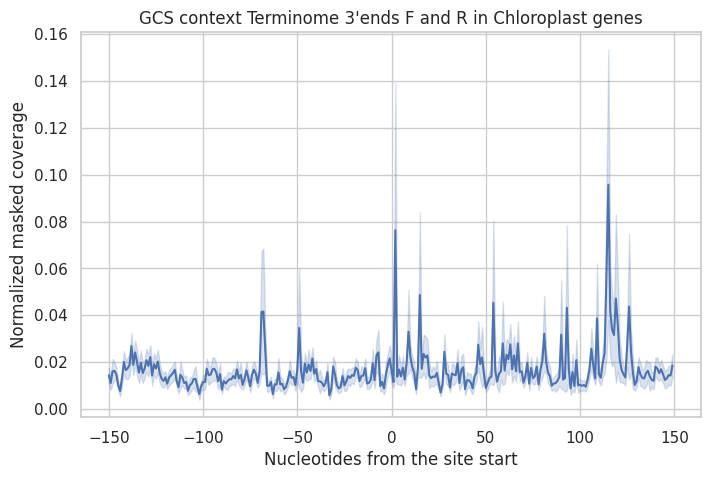

In [ ]:
plot_signal_strandwise(term_norm_fpkm['WT_3\'ends_F_norm'].to_numpy(), term_norm_fpkm['WT_3\'ends_R_norm'].to_numpy(), filtered_gates, 150, 
                       'GCS context Terminome 3\'ends F and R in Chloroplast genes', 'Normalized masked coverage', 'se')
plt.savefig('pic_svg/gcs_terminome_3_both_masked_461_150.svg', dpi = 300)

# Random sites simulations

In [ ]:
def get_random_gates_in_genes(seq_len: int, 
                            orig_gates: np.array, 
                            width: int, 
                            n: int, 
                            fpkm,
                            num_replicates: int = 1,
                            exclude_orig: bool = True, # whether to exclude original gates vicinities
                            random_seed: int = None):
    
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # always exclude sequence head/tail
    always_forbidden = np.zeros(seq_len, dtype=bool)
    always_forbidden[:width] = True
    always_forbidden[seq_len-width:] = True
    
    # create allowed regions (genic regions minus buffers)
    allowed = np.zeros(seq_len, dtype=bool)
    for _, gene in fpkm.iterrows():
        gene_start = gene['st']
        gene_end = gene['end']
        region_start = gene_start + width
        region_end = gene_end - width - 4  # -4 for gate length
        if region_start < region_end:
            allowed[region_start:region_end] = True
    
    # generate each replicate independently
    all_replicates = []
    
    for _ in range(num_replicates):
        # for each replicate, create a fresh forbidden mask
        forbidden = always_forbidden.copy()
        
        # conditionally exclude original gates neighborhoods
        if exclude_orig and orig_gates.size > 0:
            for gate in orig_gates[:, 0]:
                start = max(0, gate - 2*width)
                end = min(seq_len, gate + 2*width)
                forbidden[start:end] = True
        
        # get valid positions for this replicate
        valid_positions = np.where(~forbidden & allowed)[0]
        
        if len(valid_positions) < n:
            raise ValueError(
                f"Only {len(valid_positions)} valid positions available in a replicate, "
                f"cannot sample {n} gates"
            )
        
        # sample for this replicate
        sampled_pos = np.random.choice(valid_positions, size=n, replace=False)
        replicate_gates = np.column_stack([sampled_pos, sampled_pos + 4])
        all_replicates.append(replicate_gates)
    
    return np.array(all_replicates)


In [ ]:
def calculate_binned_signal(forward_signal: np.array, 
                          reverse_signal: np.array, 
                          gates: np.array, 
                          width: int = 150,
                          bin_size: int = 4,
                          flip_reverse: bool = True):
   
    total_window = 2 * width + 4  # +4 for gate length
    n_bins = total_window // bin_size
    
    # handle single replicate case (convert to 1xNx2)
    if gates.ndim == 2:
        gates = gates[np.newaxis, ...]
    
    n_replicates = gates.shape[0]
    all_binned_signals = []
    
    for rep_idx in range(n_replicates):
        replicate_gates = gates[rep_idx]
        binned_signals = np.zeros((len(replicate_gates), n_bins))
        
        for gate_idx, (l, r) in enumerate(replicate_gates):
            # convert to 0-based indexing
            center = l - 1
            start = center - width
            end = center + width + 4  # +4 for gate length
            
            # skip gates near boundaries
            if start < 0 or end > len(forward_signal):
                binned_signals[gate_idx] = np.nan
                continue
                
            f_signal = forward_signal[start:end]
            r_signal = reverse_signal[start:end]
            
            if flip_reverse:
                r_signal = r_signal[::-1]  # flip reverse strand
            
            # combine strands
            combined = f_signal + r_signal
            
            # bin the signal
            binned = combined.reshape(-1, bin_size).mean(axis=1)
            binned_signals[gate_idx] = binned
        
        all_binned_signals.append(binned_signals)
    
    # stack replicates and compute means
    all_binned_signals = np.array(all_binned_signals)
    return all_binned_signals

In [ ]:
def plot_terminome_heatmap_with_pvalues(mean_binned_signals, width=150, bin_size=8, 
                                      signal_cmap="viridis"):
    """
    Plot terminome signal with perfect alignment and improved labeling using sns.heatmap.
    """

    HIGH_PVALUE_COLOR = "#E64B35"
    LOW_PVALUE_COLOR = "#357EBD"
    SIG_MARKER_COLOR = "#000000"    
    SIG_LINE_COLOR = "#666666"      

    total_window = 2 * width + 4
    n_bins = total_window // bin_size
    bin_centers = np.arange(n_bins) * bin_size + (bin_size / 2) - width
    key_positions = [-width, 0, width]
    key_bins = [np.argmin(np.abs(bin_centers - pos)) for pos in key_positions]
    
    original_signal = mean_binned_signals[0]
    random_signals = mean_binned_signals[1:]
    
    # calculate p-values
    p_high = np.array([np.mean(random_signals[:, i] >= original_signal[i]) for i in range(n_bins)])
    p_low = np.array([np.mean(random_signals[:, i] <= original_signal[i]) for i in range(n_bins)])

    _, p_high_corr, _, _ = multipletests(p_high, method='fdr_bh')
    _, p_low_corr, _, _ = multipletests(p_low, method='fdr_bh')
    
    fig = plt.figure(figsize=(10, 12), constrained_layout=True)
    gs = fig.add_gridspec(4, 2, height_ratios=[1, 12, 2, 2], 
                         width_ratios=[0.98, 0.02],
                         hspace=0.02
                         )
    
    vmin = min(np.min(original_signal), np.min(random_signals))
    vmax = max(np.max(original_signal), np.max(random_signals))
    
    # 1. true signal subplot (taller)
    ax_true = fig.add_subplot(gs[0, 0])
    sns.heatmap(original_signal.reshape(1, -1), 
                cmap=signal_cmap,
                vmin=vmin, vmax=vmax,
                cbar=False,
                ax=ax_true)
    ax_true.set_yticks([])
    ax_true.text(-0.05, 0.5, "GCS in genes", 
                  rotation=90, va='center', ha='right',
                  transform=ax_true.transAxes)
    ax_true.set_xticks([])
    
    # 2. random replicates heatmap
    ax_random = fig.add_subplot(gs[1, 0])
    sns.heatmap(random_signals,
                cmap=signal_cmap,
                vmin=vmin, vmax=vmax,
                cbar=False,
                ax=ax_random)
    ax_random.set_yticks([])
    ax_random.text(-0.05, 0.5, "Random sites in genes", 
                  rotation=90, va='center', ha='right',
                  transform=ax_random.transAxes)
    ax_random.set_xticks([])
    
    cbar_ax = fig.add_subplot(gs[0:2, 1])
    sm = plt.cm.ScalarMappable(cmap=signal_cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Normalized Terminome-Seq Signal')
    
    # 3. p-value plots 
    ax_high = fig.add_subplot(gs[2, 0])
    ax_low = fig.add_subplot(gs[3, 0])
    
    x = np.arange(n_bins) + 0.5  # align with heatmap bins
    
    ax_high.plot(x, p_high_corr, 'o-', color=HIGH_PVALUE_COLOR, markersize=4, linewidth=1)
    ax_high.axhline(0.05, color=SIG_LINE_COLOR, linestyle='--')
    ax_high.set_ylabel('P(GCS ≥ Random)', fontsize=10, rotation=90)
    ax_high.yaxis.set_label_position("right")
    ax_high.yaxis.tick_right()
    ax_high.set_ylim(-0.05, 1.05)
    ax_high.set_xlim(0, x[-1]+0.5)
    ax_high.grid(False)

    ax_low.plot(x, p_low_corr, 'o-', color=LOW_PVALUE_COLOR, markersize=4, linewidth=1)
    ax_low.axhline(0.05, color=SIG_LINE_COLOR, linestyle='--')
    ax_low.set_ylabel('P(GCS ≤ Random)', fontsize=10, rotation=90)
    ax_low.yaxis.set_label_position("right")
    ax_low.yaxis.tick_right()
    ax_low.set_ylim(-0.05, 1.05)
    ax_low.set_xlim(0, x[-1]+0.5)
    ax_low.set_xlabel('Position relative to GCS start (nt)')
    ax_low.grid(False)
    
    # mark significant points
    for ax, pvals in [(ax_high, p_high_corr), (ax_low, p_low_corr)]:
        sig = np.where(pvals <= 0.05)[0]
        for bin_idx in sig:
            ax.text(x[bin_idx], pvals[bin_idx]+0.05, "*", 
                   ha='center', va='bottom', color=SIG_MARKER_COLOR, fontsize=10)
    
    for ax in [ax_true, ax_random, ax_high, ax_low]:
        ax.set_xticks(np.array(key_bins) + 0.5)
        ax.set_xticklabels([f"{int(pos)}" for pos in key_positions])
    
    plt.suptitle('Terminome-Seq Signal Analysis', y=1.02)
    return fig, (ax_true, ax_random, ax_high, ax_low), p_high_corr, p_low_corr

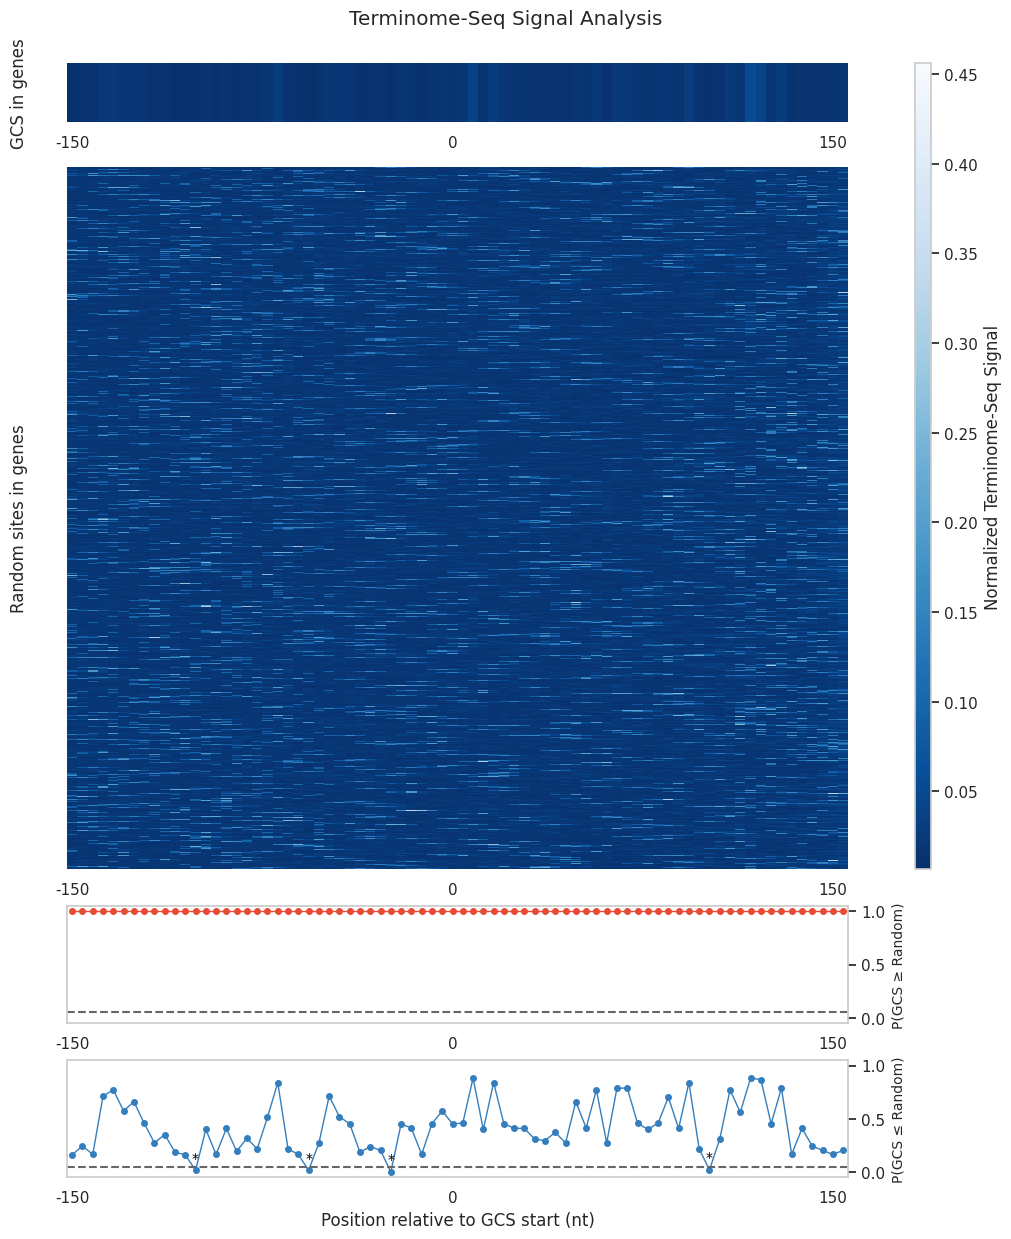

Columns with significantly higher GCS signal: 0.0 % (0 out of 76)
Columns with significantly lower GCS signal: 5.26 % (4 out of 76)
Columns with non-significant results for both hypotheses: 94.74 % (72 out of 76)


In [ ]:
random_gates_replicates = get_random_gates_in_genes(
    seq_len=120000,
    orig_gates=filtered_gates,
    width=150,
    n=len(filtered_gates),
    fpkm=fpkm,
    num_replicates=5000, 
    exclude_orig=False,  
    random_seed=42
)

all_gates = np.concatenate([filtered_gates[np.newaxis, ...], random_gates_replicates])

binned_signals = calculate_binned_signal(
    forward_signal=term_norm_fpkm['WT_3\'ends_F_norm'].to_numpy(),
    reverse_signal=term_norm_fpkm['WT_3\'ends_R_norm'].to_numpy(),
    gates=all_gates,
    width=150,
    bin_size=4,
    flip_reverse=True
)

mean_binned_signals = np.nanmean(binned_signals, axis=1)

fig, axes, pvals, pvals_lower = plot_terminome_heatmap_with_pvalues(
    mean_binned_signals,
    width=150,
    bin_size=4,
    signal_cmap="Blues_r"
)
plt.savefig('pic_svg/random_site_simulations.svg', dpi=300)
plt.show()

print(f'Columns with significantly higher GCS signal: {np.round(np.mean(pvals <= 0.05) * 100, 2)} % ({np.sum(pvals <= 0.05)} out of {len(pvals)})')
print(f'Columns with significantly lower GCS signal: {np.round(np.mean(pvals_lower <= 0.05) * 100, 2)} % ({np.sum(pvals_lower <= 0.05)} out of {len(pvals_lower)})')
print(f'Columns with non-significant results for both hypotheses: {np.round(np.mean((pvals > 0.05) & (pvals_lower > 0.05)) * 100, 2)} % ({np.sum((pvals > 0.05) & (pvals_lower > 0.05))} out of {len(pvals_lower)})')

# Random sites outside GCSs vicinity

In [2]:
def get_random_gates(seq_len: int, orig_gates: np.array, width: int, n: int):
    """ 
    Get n random gates in the sequence without replacement & without intersection with the gates
    """
    rest_seq = np.arange(seq_len)
    index_delete = [0, np.arange(width)]
    index_delete += [np.arange(seq_len-width, seq_len)]

    for i in orig_gates[:, 0]:
        index_delete += [np.arange(i-2*width, i+2*width)]
    index_delete = np.hstack(index_delete)

    rest_seq = np.delete(rest_seq, index_delete)
    random_gates = np.random.choice(rest_seq, n, replace=False)
    random_gates = np.array([random_gates, random_gates+4]).T
    return random_gates

In [18]:
random_gates = get_random_gates(120000, filtered_gates, 150, len(filtered_gates)*18)

epsilon = 150 # exclude gates which epsilon-neighbourhood is outside genes
mask = ((fpkm['st'].values[:, None] <= random_gates[:, 0] - epsilon) & 
        (fpkm['end'].values[:, None] >= random_gates[:, 0] - epsilon)) & \
        ((fpkm['st'].values[:, None] <= random_gates[:, 1] + epsilon) & 
         (fpkm['end'].values[:, None] >= random_gates[:, 1] + epsilon))
filtered_random_gates = random_gates[np.any(mask, axis=0)]

filtered_random_gates.shape

(482, 2)

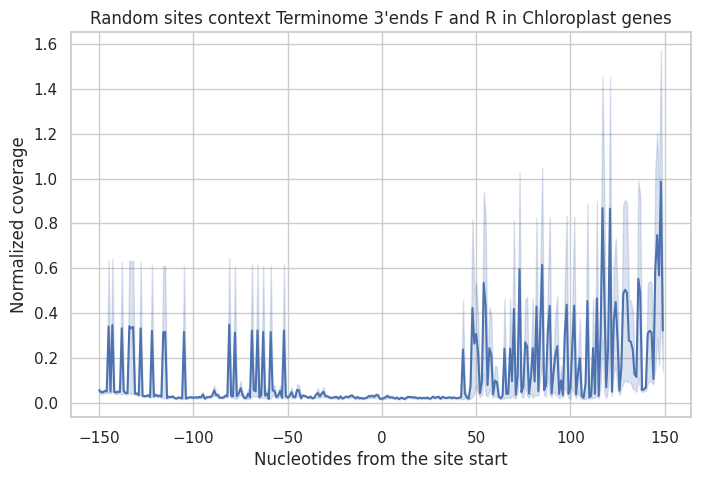

In [19]:
plot_signal_strandwise(term_norm_fpkm['WT_3\'ends_F_norm'].to_numpy(), term_norm_fpkm['WT_3\'ends_R_norm'].to_numpy(), filtered_random_gates, 150, 
                       'Random sites context Terminome 3\'ends F and R in Chloroplast genes', 'Normalized coverage', 'se')
# plt.savefig('random_terminome_3_both_masked.svg', dpi = 300)

# Compare signal in selected intervals

In [ ]:
gcs_signals = []
genes_signals = []
width = 50
f = (-50, 50)
mask_nt = 10
mask_nt_f = 10 # currently should be equal to mask_nt (symmetric intervals)

exclude_regions = []
check = []

# generate gcs_signals excluding gene ends
for l, r in filtered_gates:
    if l-1 < width or 120000 < l-1+width:
        continue
    start_idx = l-1+f[0]
    end_idx = l-1+f[1]
    exclude_regions.append((start_idx, end_idx))

    # Adjust indices to exclude gene ends
    for start, end in fpkm[['st', 'end']].values:
        if start > end_idx:
            break
        if end_idx >= end - mask_nt and end_idx <= end + mask_nt_f:
            end_idx = end - mask_nt
        if start_idx >= start - mask_nt_f and start_idx <= start + mask_nt:
            start_idx = start + mask_nt

    signal = term_norm_fpkm['WT_3\'ends_F_norm'].to_numpy()[start_idx-1:end_idx-1] + \
             term_norm_fpkm['WT_3\'ends_R_norm'].to_numpy()[start_idx-1:end_idx-1][::-1]
    gcs_signals.append(signal)

gcs_signals = np.array([x for xs in gcs_signals for x in xs])

# generate genes_signals excluding regions defined in exclude_regions and gene ends

term_norm_fpkm_mod = term_norm_fpkm.copy()
for start, end in exclude_regions:
    term_norm_fpkm_mod[start:end] = np.nan

for start, end in fpkm[['st', 'end']].values:
    signal = term_norm_fpkm_mod['WT_3\'ends_F_norm'].to_numpy()[start-1:end-1-mask_nt] + \
    term_norm_fpkm_mod['WT_3\'ends_R_norm'].to_numpy()[start-1+mask_nt:end-1][::-1]
    genes_signals += [signal[~np.isnan(signal)]]
genes_signals = np.array([x for xs in genes_signals for x in xs])



In [116]:
gcs_signals.shape

(57862,)

In [117]:
genes_signals.shape

(28878,)

In [118]:
gcs_cp_m = np.mean(gcs_signals)
genes_cp_m = np.mean(genes_signals)

wtest_cp_1 = sps.mannwhitneyu(gcs_signals, genes_signals)[1]

kstest_cp_1 = sps.kstest(gcs_signals, genes_signals)[1]

In [119]:
pvals = [wtest_cp_1, kstest_cp_1]
reject, pvals_corrected = multipletests(np.array(pvals), alpha=0.05, method='h', is_sorted=False, returnsorted=False)[:2]

In [120]:
pvals_corrected

array([2.25701909e-030, 1.99209705e-100])

In [121]:
pd.DataFrame({
              'GCS in genes -50:+50 nt from start mean Terminome-seq signal': gcs_cp_m,
              'Genes outside GCS mean Terminome-seq signal': genes_cp_m,
              'MannWhitneyU GCS vs genes corrected p-value': pvals_corrected[0],
              'KStest GCS vs genes corrected p-value': pvals_corrected[1],

              }, index=['Chloroplasts'])

,GCS in genes -50:+50 nt from start mean Terminome-seq signal,Genes outside GCS mean Terminome-seq signal,MannWhitneyU GCS vs genes corrected p-value,KStest GCS vs genes corrected p-value
Chloroplasts,0.017877,0.07077,2.257019e-30,1.992097e-100


Text(0.5, 1.0, 'Terminome-seq signal dicstribution, chloroplast genes')

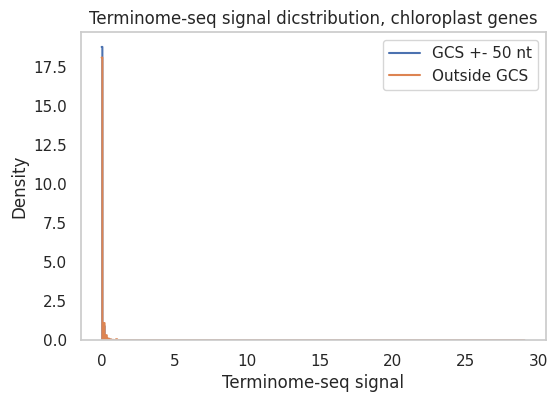

In [ ]:
plt.figure(figsize=(6, 4))
binwidth = 0.05
sns.histplot(gcs_signals, stat='density', kde=False, bins=np.arange(min(gcs_signals), max(gcs_signals) + binwidth, binwidth), label='GCS +- 50 nt', element="step", fill=False)
sns.histplot(genes_signals, stat='density', kde=False, bins=np.arange(min(gcs_signals), max(gcs_signals) + binwidth, binwidth), label='Outside GCS', element="step", fill=False)

plt.xlabel('Terminome-seq signal')
plt.ylabel('Density')

plt.legend()
plt.grid(False)
plt.title('Terminome-seq signal dicstribution, chloroplast genes')